# Dataset Exploration: Quick Overview

This notebook provides a quick exploration of the following datasets:

- **archive_2**: Food.com recipes and interactions
- **archive_3**: Recipe reviews dataset
- **archive_6**: Food coding dataset
- **onlinefoods.csv**: Online food orders dataset

Goal: Understand data structure and prepare for TF-IDF analysis


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set data directory
DATA_DIR = Path('../data')

print("Environment setup complete!")

Environment setup complete!


## 1. Archive_2: Food.com Dataset

Contains recipes and user interactions from Food.com


In [2]:
# Load archive_2 datasets
archive_2_dir = DATA_DIR / 'archive_2'

print("=" * 80)
print("ARCHIVE_2: Food.com Dataset")
print("=" * 80)

# Load recipes
recipes_a2 = pd.read_csv(archive_2_dir / 'PP_recipes.csv')
print(f"\n📊 Recipes Dataset: {recipes_a2.shape}")
print(f"Columns: {list(recipes_a2.columns)}")
print("\nFirst 3 rows:")
display(recipes_a2.head(3))

# Data types and missing values
print("\n📋 Data Info:")
print(recipes_a2.info())
print("\n🔍 Missing Values:")
print(recipes_a2.isnull().sum())

# Basic statistics
print("\n📈 Numeric Columns Statistics:")
display(recipes_a2.describe())

ARCHIVE_2: Food.com Dataset

📊 Recipes Dataset: (178265, 8)
Columns: ['id', 'i', 'name_tokens', 'ingredient_tokens', 'steps_tokens', 'techniques', 'calorie_level', 'ingredient_ids']

First 3 rows:


,id,i,name_tokens,ingredient_tokens,steps_tokens,techniques,calorie_level,ingredient_ids
0,424415,23,"[40480, 37229, 2911, 1019, 249, 6878, 6878, 28...","[[2911, 1019, 249, 6878], [1353], [6953], [153...","[40480, 40482, 21662, 481, 6878, 500, 246, 161...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[389, 7655, 6270, 1527, 3406]"
1,146223,96900,"[40480, 18376, 7056, 246, 1531, 2032, 40481]","[[17918], [25916], [2507, 6444], [8467, 1179],...","[40480, 40482, 729, 2525, 10906, 485, 43, 8393...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[2683, 4969, 800, 5298, 840, 2499, 6632, 7022,..."
2,312329,120056,"[40480, 21044, 16954, 8294, 556, 10837, 40481]","[[5867, 24176], [1353], [6953], [1301, 11332],...","[40480, 40482, 8240, 481, 24176, 296, 1353, 66...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",1,"[1257, 7655, 6270, 590, 5024, 1119, 4883, 6696..."



📋 Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 178265 entries, 0 to 178264
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   id                 178265 non-null  int64
 1   i                  178265 non-null  int64
 2   name_tokens        178265 non-null  str  
 3   ingredient_tokens  178265 non-null  str  
 4   steps_tokens       178265 non-null  str  
 5   techniques         178265 non-null  str  
 6   calorie_level      178265 non-null  int64
 7   ingredient_ids     178265 non-null  str  
dtypes: int64(3), str(5)
memory usage: 201.0 MB
None

🔍 Missing Values:
id                   0
i                    0
name_tokens          0
ingredient_tokens    0
steps_tokens         0
techniques           0
calorie_level        0
ingredient_ids       0
dtype: int64

📈 Numeric Columns Statistics:


,id,i,calorie_level
count,178265.000000,178265.000000,178265.000000
mean,213461.803007,89132.000000,0.863192
std,138266.712754,51460.817206,0.791486
min,38.000000,0.000000,0.000000
25%,94576.000000,44566.000000,0.000000
50%,196312.000000,89132.000000,1.000000
75%,320562.000000,133698.000000,2.000000
max,537716.000000,178264.000000,2.000000


In [3]:
# Explore text columns for TF-IDF (if available)
print("\n🔤 Text Column Analysis (for TF-IDF):")

# Check for text columns (common names: name, description, ingredients, steps, tags)
text_cols = [col for col in recipes_a2.columns if any(keyword in col.lower()
             for keyword in ['name', 'description', 'ingredient', 'step', 'tag', 'text'])]

print(f"\nPotential text columns: {text_cols}")

if text_cols:
    for col in text_cols:
        print(f"\n--- {col} ---")
        print(f"Sample values:")
        print(recipes_a2[col].head(3).values)
        if recipes_a2[col].dtype == 'object':
            avg_length = recipes_a2[col].astype(str).str.len().mean()
            print(f"Average length: {avg_length:.1f} characters")


🔤 Text Column Analysis (for TF-IDF):

Potential text columns: ['name_tokens', 'ingredient_tokens', 'steps_tokens', 'ingredient_ids']

--- name_tokens ---
Sample values:
<ArrowStringArray>
['[40480, 37229, 2911, 1019, 249, 6878, 6878, 2839, 1781, 40481]',
                   '[40480, 18376, 7056, 246, 1531, 2032, 40481]',
                 '[40480, 21044, 16954, 8294, 556, 10837, 40481]']
Length: 3, dtype: str

--- ingredient_tokens ---
Sample values:
<ArrowStringArray>
[                                                                                                                                                                                                          '[[2911, 1019, 249, 6878], [1353], [6953], [15341, 3261], [2056, 857, 643, 1631, 20480]]',
                                                                                                                                           '[[17918], [25916], [2507, 6444], [8467, 1179], [8780], [6812], [4370, 2653, 18376], [2654, 55


📊 Interactions Train: (698901, 6)


,user_id,recipe_id,date,rating,u,i
0,2046,4684,2000-02-25,5.0,22095,44367
1,2046,517,2000-02-25,5.0,22095,87844
2,1773,7435,2000-03-13,5.0,24732,138181



⭐ Rating Distribution:
rating
0.0     16957
1.0      3341
2.0      6852
3.0     25781
4.0    127402
5.0    518568
Name: count, dtype: int64


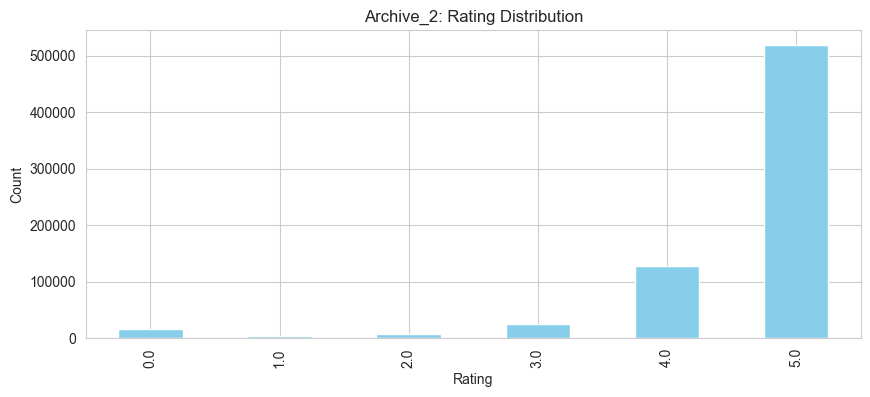

In [4]:
# Load user interactions
interactions_train = pd.read_csv(archive_2_dir / 'interactions_train.csv')
print(f"\n📊 Interactions Train: {interactions_train.shape}")
display(interactions_train.head(3))

# Rating distribution
if 'rating' in interactions_train.columns:
    print("\n⭐ Rating Distribution:")
    print(interactions_train['rating'].value_counts().sort_index())

    plt.figure(figsize=(10, 4))
    interactions_train['rating'].value_counts(
    ).sort_index().plot(kind='bar', color='skyblue')
    plt.title('Archive_2: Rating Distribution')
    plt.xlabel('Rating')
    plt.ylabel('Count')
    plt.show()

In [5]:
# Load users data
users_a2 = pd.read_csv(archive_2_dir / 'PP_users.csv')
print(f"\n👥 Users Dataset: {users_a2.shape}")
display(users_a2.head(3))
print(
    f"\nUnique users: {users_a2.shape[0] if 'user_id' in users_a2.columns else 'N/A'}")


👥 Users Dataset: (25076, 6)


,u,techniques,items,n_items,ratings,n_ratings
0,0,"[8, 0, 0, 5, 6, 0, 0, 1, 0, 9, 1, 0, 0, 0, 1, ...","[1118, 27680, 32541, 137353, 16428, 28815, 658...",31,"[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.0, 4.0, ...",31
1,1,"[11, 0, 0, 2, 12, 0, 0, 0, 0, 14, 5, 0, 0, 0, ...","[122140, 77036, 156817, 76957, 68818, 155600, ...",39,"[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...",39
2,2,"[13, 0, 0, 7, 5, 0, 1, 2, 1, 11, 0, 1, 0, 0, 1...","[168054, 87218, 35731, 1, 20475, 9039, 124834,...",27,"[3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, ...",27



Unique users: N/A


## 2. Archive_3: Recipe Reviews Dataset


In [6]:
# Load archive_3 datasets
archive_3_dir = DATA_DIR / 'archive_3'

print("=" * 80)
print("ARCHIVE_3: Recipe Reviews Dataset")
print("=" * 80)

# Check if parquet or csv is available
if (archive_3_dir / 'recipes.parquet').exists():
    recipes_a3 = pd.read_parquet(archive_3_dir / 'recipes.parquet')
    print("\n✅ Loaded recipes.parquet")
else:
    recipes_a3 = pd.read_csv(archive_3_dir / 'recipes.csv')
    print("\n✅ Loaded recipes.csv")

print(f"\n📊 Recipes Dataset: {recipes_a3.shape}")
print(f"Columns: {list(recipes_a3.columns)}")
display(recipes_a3.head(3))

# Data info
print("\n📋 Data Info:")
print(recipes_a3.info())
print("\n🔍 Missing Values:")
missing = recipes_a3.isnull().sum()
print(missing[missing > 0])

ARCHIVE_3: Recipe Reviews Dataset

✅ Loaded recipes.parquet

📊 Recipes Dataset: (522517, 28)
Columns: ['RecipeId', 'Name', 'AuthorId', 'AuthorName', 'CookTime', 'PrepTime', 'TotalTime', 'DatePublished', 'Description', 'Images', 'RecipeCategory', 'Keywords', 'RecipeIngredientQuantities', 'RecipeIngredientParts', 'AggregatedRating', 'ReviewCount', 'Calories', 'FatContent', 'SaturatedFatContent', 'CholesterolContent', 'SodiumContent', 'CarbohydrateContent', 'FiberContent', 'SugarContent', 'ProteinContent', 'RecipeServings', 'RecipeYield', 'RecipeInstructions']


,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions
0,38.0,Low-Fat Berry Blue Frozen Dessert,1533,Dancer,PT24H,PT45M,PT24H45M,1999-08-09 21:46:00+00:00,Make and share this Low-Fat Berry Blue Frozen ...,[https://img.sndimg.com/food/image/upload/w_55...,...,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,NaN,"[Toss 2 cups berries with sugar., Let stand fo..."
1,39.0,Biryani,1567,elly9812,PT25M,PT4H,PT4H25M,1999-08-29 13:12:00+00:00,Make and share this Biryani recipe from Food.com.,[https://img.sndimg.com/food/image/upload/w_55...,...,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,NaN,[Soak saffron in warm milk for 5 minutes and p...
2,40.0,Best Lemonade,1566,Stephen Little,PT5M,PT30M,PT35M,1999-09-05 19:52:00+00:00,This is from one of my first Good House Keepi...,[https://img.sndimg.com/food/image/upload/w_55...,...,0.0,0.0,1.8,81.5,0.4,77.2,0.3,4.0,NaN,"[Into a 1 quart Jar with tight fitting lid, pu..."



📋 Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 522517 entries, 0 to 522516
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   RecipeId                    522517 non-null  float64            
 1   Name                        522517 non-null  str                
 2   AuthorId                    522517 non-null  int32              
 3   AuthorName                  522517 non-null  str                
 4   CookTime                    439972 non-null  str                
 5   PrepTime                    522517 non-null  str                
 6   TotalTime                   522517 non-null  str                
 7   DatePublished               522517 non-null  datetime64[us, UTC]
 8   Description                 522512 non-null  str                
 9   Images                      522516 non-null  object             
 10  RecipeCategory              521766 non-nu

In [7]:
# Explore text columns for TF-IDF
print("\n🔤 Text Column Analysis (for TF-IDF):")

text_cols_a3 = [col for col in recipes_a3.columns if any(keyword in col.lower()
                for keyword in ['name', 'description', 'ingredient', 'direction', 'tag', 'text', 'title'])]

print(f"Text columns found: {text_cols_a3}")

if text_cols_a3:
    for col in text_cols_a3[:3]:  # Show first 3 text columns
        print(f"\n--- {col} ---")
        print(f"Sample:")
        print(recipes_a3[col].dropna().iloc[0]
              [:200] + "...")  # First 200 chars
        if recipes_a3[col].dtype == 'object':
            avg_length = recipes_a3[col].astype(str).str.len().mean()
            print(f"Average length: {avg_length:.1f} characters")
            print(f"Non-null count: {recipes_a3[col].notna().sum()}")


🔤 Text Column Analysis (for TF-IDF):
Text columns found: ['Name', 'AuthorName', 'Description', 'RecipeIngredientQuantities', 'RecipeIngredientParts']

--- Name ---
Sample:
Low-Fat Berry Blue Frozen Dessert...

--- AuthorName ---
Sample:
Dancer...

--- Description ---
Sample:
Make and share this Low-Fat Berry Blue Frozen Dessert recipe from Food.com....



✅ Loaded reviews.parquet

📊 Reviews Dataset: (1401982, 8)


,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
0,2,992,2008,gayg msft,5,better than any you can get at a restaurant!,2000-01-25 21:44:00+00:00,2000-01-25 21:44:00+00:00
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17 16:49:59+00:00,2001-10-17 16:49:59+00:00
2,9,4523,2046,Gay Gilmore ckpt,2,i think i did something wrong because i could ...,2000-02-25 09:00:00+00:00,2000-02-25 09:00:00+00:00



⭐ Rating Distribution:
Rating
0      76248
1      16559
2      17597
3      50279
4     229217
5    1012082
Name: count, dtype: int64


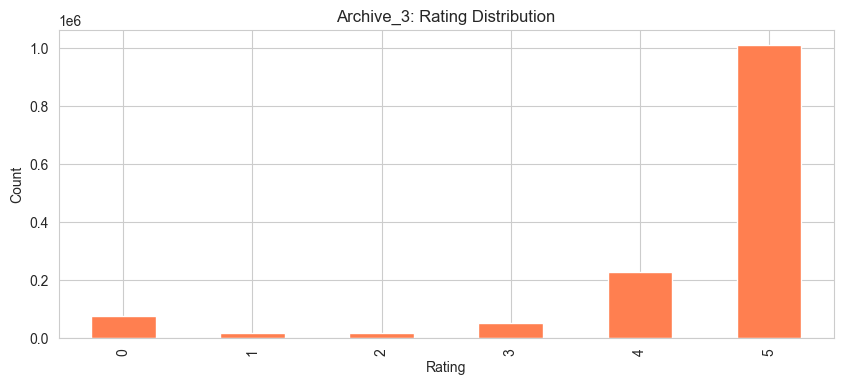


💬 Review text columns: ['Review']
Sample review from 'Review':
⚠️ 该列不是文本类型，值为: 0          better than any you can get at a restaurant!
1     I cut back on the mayo, and made up the differ...
2     i think i did something wrong because i could ...
3     easily the best i have ever had.  juicy flavor...
4                                    An excellent dish.
5                love it, but without the bean sprouts.
6     chewy goodness, not crispy at all. i even thre...
7     Would someone please check the Nutrition Facts...
8                            thought this was terrific!
9     this is absolutely delicious.  i even served i...
10     a little greasy, but a huge hit with the guests.
11    leeks on a pizza?!  it was really delicious.  ...
12    I deleted the bean sprouts and replaced them w...
13                          Where does the bbq come in 
14    This was a fine sandwich, I'll definitely be m...
15    Very simple recipe to make! This is a refreshi...
16                      

In [8]:
# Load reviews
if (archive_3_dir / 'reviews.parquet').exists():
    reviews_a3 = pd.read_parquet(archive_3_dir / 'reviews.parquet')
    print("\n✅ Loaded reviews.parquet")
else:
    reviews_a3 = pd.read_csv(archive_3_dir / 'reviews.csv')
    print("\n✅ Loaded reviews.csv")

print(f"\n📊 Reviews Dataset: {reviews_a3.shape}")
display(reviews_a3.head(3))

# Rating distribution
if 'rating' in reviews_a3.columns or 'Rating' in reviews_a3.columns:
    rating_col = 'rating' if 'rating' in reviews_a3.columns else 'Rating'
    print(f"\n⭐ Rating Distribution:")
    print(reviews_a3[rating_col].value_counts().sort_index())

    plt.figure(figsize=(10, 4))
    reviews_a3[rating_col].value_counts().sort_index().plot(
        kind='bar', color='coral')
    plt.title('Archive_3: Rating Distribution')
    plt.xlabel('Rating')
    plt.ylabel('Count')
    plt.show()

# Check for review text (改进匹配逻辑，排除ID列)
review_text_cols = [col for col in reviews_a3.columns
                    if any(keyword in col.lower() for keyword in ['review', 'text', 'comment', 'feedback'])
                    and 'id' not in col.lower()  # 排除ID列
                    and 'Id' not in col]          # 排除ReviewId等

if review_text_cols:
    print(f"\n💬 Review text columns: {review_text_cols}")

    # 取第一个真正的文本列
    text_col = review_text_cols[0]
    sample_text = reviews_a3[text_col].dropna().iloc[:20]

    print(f"Sample review from '{text_col}':")
    # 检查是否为字符串再切片，避免标量值报错
    if isinstance(sample_text, str):
        print(sample_text[:300])
    else:
        print(f"⚠️ 该列不是文本类型，值为: {sample_text}")
else:
    print("\n⚠️ 未找到评论文本列")
    print(f"可用列: {reviews_a3.columns.tolist()}")

## 3. Archive_6: Food Coding Dataset


In [9]:
# Load archive_6 dataset
archive_6_dir = DATA_DIR / 'archive_6'

print("=" * 80)
print("ARCHIVE_6: Food Coding Dataset")
print("=" * 80)

food_coded = pd.read_csv(archive_6_dir / 'food_coded.csv')
print(f"\n📊 Food Coded Dataset: {food_coded.shape}")
print(f"Columns: {list(food_coded.columns)}")
display(food_coded.head(3))

# Data info
print("\n📋 Data Info:")
print(food_coded.info())
print("\n🔍 Missing Values:")
missing = food_coded.isnull().sum()
print(missing[missing > 0])

# Statistical summary
print("\n📈 Statistics:")
display(food_coded.describe())

ARCHIVE_6: Food Coding Dataset

📊 Food Coded Dataset: (125, 61)
Columns: ['GPA', 'Gender', 'breakfast', 'calories_chicken', 'calories_day', 'calories_scone', 'coffee', 'comfort_food', 'comfort_food_reasons', 'comfort_food_reasons_coded', 'cook', 'comfort_food_reasons_coded.1', 'cuisine', 'diet_current', 'diet_current_coded', 'drink', 'eating_changes', 'eating_changes_coded', 'eating_changes_coded1', 'eating_out', 'employment', 'ethnic_food', 'exercise', 'father_education', 'father_profession', 'fav_cuisine', 'fav_cuisine_coded', 'fav_food', 'food_childhood', 'fries', 'fruit_day', 'grade_level', 'greek_food', 'healthy_feeling', 'healthy_meal', 'ideal_diet', 'ideal_diet_coded', 'income', 'indian_food', 'italian_food', 'life_rewarding', 'marital_status', 'meals_dinner_friend', 'mother_education', 'mother_profession', 'nutritional_check', 'on_off_campus', 'parents_cook', 'pay_meal_out', 'persian_food', 'self_perception_weight', 'soup', 'sports', 'thai_food', 'tortilla_calories', 'turkey_ca

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.



📋 Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    str    
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    str    
 8   comfort_food_reasons          123 non-null    str    
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  di

,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food_reasons_coded,cook,comfort_food_reasons_coded.1,cuisine,...,persian_food,self_perception_weight,soup,sports,thai_food,tortilla_calories,turkey_calories,veggies_day,vitamins,waffle_calories
count,125.000000,125.000000,125.000000,106.000000,124.000000,125.00000,106.000000,122.000000,125.000000,108.000000,...,124.000000,124.000000,124.000000,123.000000,125.000000,124.000000,125.000000,125.000000,125.000000,125.000000
mean,1.392000,1.112000,577.320000,3.028302,505.241935,1.75200,2.698113,2.786885,2.688000,1.388889,...,2.806452,3.120968,1.217742,1.390244,3.336000,947.580645,555.040000,4.008000,1.512000,1073.400000
std,0.490161,0.316636,131.214156,0.639308,230.840506,0.43359,1.972042,1.038351,1.910987,0.974759,...,1.423824,1.115980,0.414385,0.489800,1.436528,202.090179,152.370379,1.081337,0.501867,248.667092
min,1.000000,1.000000,265.000000,2.000000,315.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,580.000000,345.000000,1.000000,1.000000,575.000000
25%,1.000000,1.000000,430.000000,3.000000,420.000000,2.00000,2.000000,2.000000,2.000000,1.000000,...,2.000000,2.000000,1.000000,1.000000,2.000000,725.000000,500.000000,3.000000,1.000000,900.000000
50%,1.000000,1.000000,610.000000,3.000000,420.000000,2.00000,2.000000,3.000000,2.000000,1.000000,...,3.000000,3.000000,1.000000,1.000000,3.000000,940.000000,500.000000,4.000000,2.000000,900.000000
75%,2.000000,1.000000,720.000000,3.000000,420.000000,2.00000,3.000000,3.000000,3.000000,1.000000,...,4.000000,4.000000,1.000000,2.000000,5.000000,1165.000000,690.000000,5.000000,2.000000,1315.000000
max,2.000000,2.000000,720.000000,4.000000,980.000000,2.00000,9.000000,5.000000,9.000000,6.000000,...,5.000000,6.000000,2.000000,2.000000,5.000000,1165.000000,850.000000,5.000000,2.000000,1315.000000


In [10]:
# Explore categorical columns
print("\n📊 Categorical Columns Distribution:")

categorical_cols = food_coded.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {list(categorical_cols)}")

for col in categorical_cols[:5]:  # Show first 5 categorical columns
    print(f"\n--- {col} ---")
    print(food_coded[col].value_counts().head(10))


📊 Categorical Columns Distribution:

Categorical columns: ['GPA', 'comfort_food', 'comfort_food_reasons', 'diet_current', 'eating_changes', 'father_profession', 'fav_cuisine', 'food_childhood', 'healthy_meal', 'ideal_diet', 'meals_dinner_friend', 'mother_profession', 'type_sports', 'weight']

--- GPA ---
GPA
3.5    13
3      11
3.2    10
3.7    10
3.3     9
3.4     9
3.6     7
3.9     7
3.8     6
2.8     5
Name: count, dtype: int64

--- comfort_food ---
comfort_food
none                                            1
chocolate, chips, ice cream                     1
frozen yogurt, pizza, fast food                 1
Pizza, Mac and cheese, ice cream                1
Ice cream, chocolate, chips                     1
Candy, brownies and soda.                       1
Chocolate, ice cream, french fries, pretzels    1
Ice cream, cheeseburgers, chips.                1
Donuts, ice cream, chips                        1
Mac and cheese, chocolate, and pasta            1
Name: count, dtype: int64

-

In [11]:
# Visualize some key features
# Identify potential food preference or coding columns
food_cols = [col for col in food_coded.columns if any(keyword in col.lower()
             for keyword in ['food', 'cuisine', 'comfort', 'fav', 'diet'])]

if food_cols:
    print(f"\n🍽️ Food-related columns: {food_cols[:5]}")

    # Plot first categorical food column
    if len(food_cols) > 0 and food_coded[food_cols[0]].dtype == 'object':
        plt.figure(figsize=(12, 5))
        food_coded[food_cols[0]].value_counts().head(
            15).plot(kind='barh', color='lightgreen')
        plt.title(f'Archive_6: {food_cols[0]} Distribution')
        plt.xlabel('Count')
        plt.tight_layout()
        plt.show()


🍽️ Food-related columns: ['comfort_food', 'comfort_food_reasons', 'comfort_food_reasons_coded', 'comfort_food_reasons_coded.1', 'cuisine']


## 4. Online Foods Dataset


In [12]:
# Load online foods dataset
print("=" * 80)
print("ONLINE FOODS: Order Dataset")
print("=" * 80)

online_foods = pd.read_csv(DATA_DIR / 'onlinefoods.csv')
print(f"\n📊 Online Foods Dataset: {online_foods.shape}")
print(f"Columns: {list(online_foods.columns)}")
display(online_foods.head(3))

# Data info
print("\n📋 Data Info:")
print(online_foods.info())
print("\n🔍 Missing Values:")
print(online_foods.isnull().sum())

# Statistics
print("\n📈 Statistics:")
display(online_foods.describe())

ONLINE FOODS: Order Dataset

📊 Online Foods Dataset: (388, 13)
Columns: ['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications', 'Family size', 'latitude', 'longitude', 'Pin code', 'Output', 'Feedback', 'Unnamed: 12']


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes



📋 Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    str    
 2   Marital Status              388 non-null    str    
 3   Occupation                  388 non-null    str    
 4   Monthly Income              388 non-null    str    
 5   Educational Qualifications  388 non-null    str    
 6   Family size                 388 non-null    int64  
 7   latitude                    388 non-null    float64
 8   longitude                   388 non-null    float64
 9   Pin code                    388 non-null    int64  
 10  Output                      388 non-null    str    
 11  Feedback                    388 non-null    str    
 12  Unnamed: 12                 388 non-null    str    
dtypes: float64(2), int64(3), str(8)


,Age,Family size,latitude,longitude,Pin code
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


In [13]:
# Explore categorical features
print("\n📊 Categorical Features:")

categorical_cols_online = online_foods.select_dtypes(
    include=['object']).columns
print(f"Categorical columns: {list(categorical_cols_online)}")

for col in categorical_cols_online:
    print(f"\n--- {col} ---")
    print(f"Unique values: {online_foods[col].nunique()}")
    print(online_foods[col].value_counts().head(10))


📊 Categorical Features:
Categorical columns: ['Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications', 'Output', 'Feedback', 'Unnamed: 12']

--- Gender ---
Unique values: 2
Gender
Male      222
Female    166
Name: count, dtype: int64

--- Marital Status ---
Unique values: 3
Marital Status
Single               268
Married              108
Prefer not to say     12
Name: count, dtype: int64

--- Occupation ---
Unique values: 4
Occupation
Student           207
Employee          118
Self Employeed     54
House wife          9
Name: count, dtype: int64

--- Monthly Income ---
Unique values: 5
Monthly Income
No Income          187
25001 to 50000      69
More than 50000     62
10001 to 25000      45
Below Rs.10000      25
Name: count, dtype: int64

--- Educational Qualifications ---
Unique values: 5
Educational Qualifications
Graduate         177
Post Graduate    174
Ph.D              23
School            12
Uneducated         2
Name: count, dtype: int64

--- 

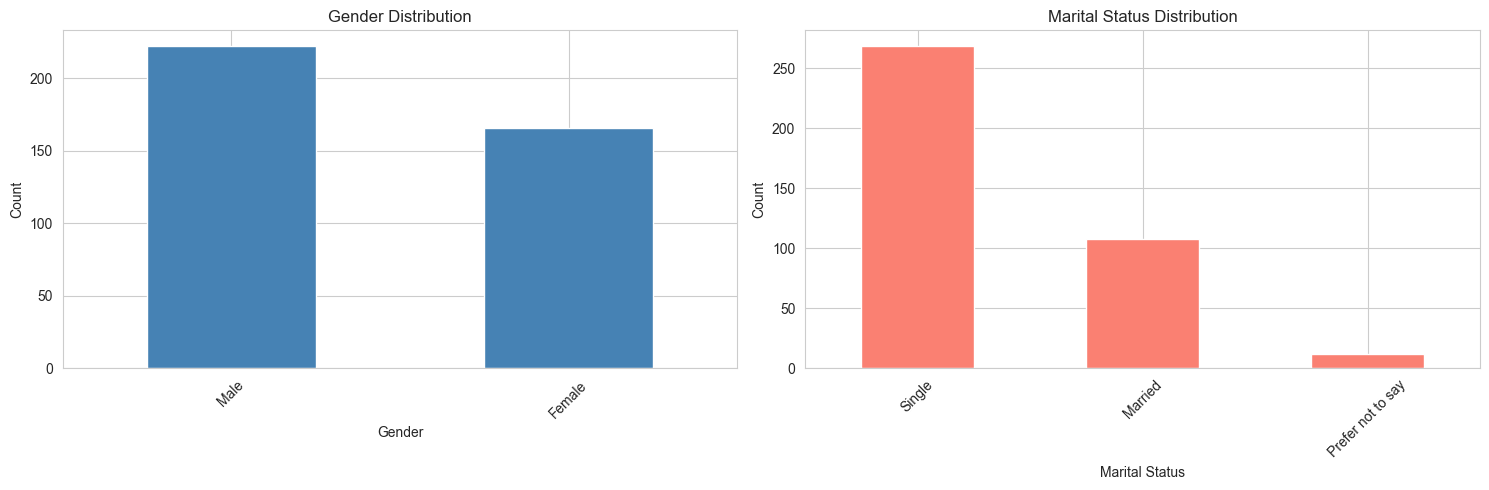

In [14]:
# Visualizations for online foods
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Distribution of a key categorical variable
if len(categorical_cols_online) > 0:
    col1 = categorical_cols_online[0]
    online_foods[col1].value_counts().head(10).plot(
        kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title(f'{col1} Distribution')
    axes[0].set_xlabel(col1)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Another categorical variable
if len(categorical_cols_online) > 1:
    col2 = categorical_cols_online[1]
    online_foods[col2].value_counts().head(10).plot(
        kind='bar', ax=axes[1], color='salmon')
    axes[1].set_title(f'{col2} Distribution')
    axes[1].set_xlabel(col2)
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Summary and TF-IDF Preparation

### Dataset Overview Summary



📊 DATASET SUMMARY


,Dataset,Rows,Columns
0,Archive_2 Recipes,178265,8
1,Archive_2 Interactions,698901,6
2,Archive_3 Recipes,522517,28
3,Archive_3 Reviews,1401982,8
4,Archive_6 Food Coded,125,61
5,Online Foods,388,13


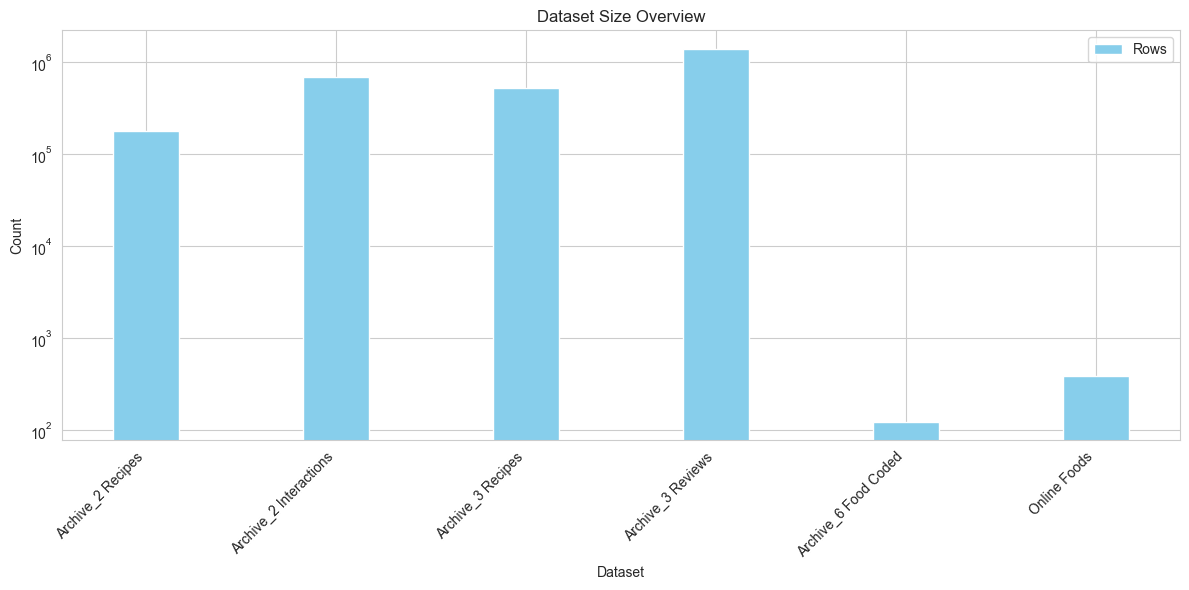

In [15]:
# Create summary table
summary_data = {
    'Dataset': ['Archive_2 Recipes', 'Archive_2 Interactions', 'Archive_3 Recipes',
                'Archive_3 Reviews', 'Archive_6 Food Coded', 'Online Foods'],
    'Rows': [recipes_a2.shape[0], interactions_train.shape[0], recipes_a3.shape[0],
             reviews_a3.shape[0], food_coded.shape[0], online_foods.shape[0]],
    'Columns': [recipes_a2.shape[1], interactions_train.shape[1], recipes_a3.shape[1],
                reviews_a3.shape[1], food_coded.shape[1], online_foods.shape[1]]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 80)
print("📊 DATASET SUMMARY")
print("=" * 80)
display(summary_df)

# Visualize summary
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(summary_df['Dataset']))
width = 0.35

bars = ax.bar(x, summary_df['Rows'], width, label='Rows', color='skyblue')
ax.set_xlabel('Dataset')
ax.set_ylabel('Count')
ax.set_title('Dataset Size Overview')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Dataset'], rotation=45, ha='right')
ax.legend()
ax.set_yscale('log')  # Log scale for better visualization

plt.tight_layout()
plt.show()

### Text Columns Identified for TF-IDF Analysis


In [16]:
print("\n" + "=" * 80)
print("🔤 TEXT COLUMNS FOR TF-IDF ANALYSIS")
print("=" * 80)

tfidf_candidates = {
    'Archive_2 Recipes': [col for col in recipes_a2.columns if recipes_a2[col].dtype == 'object'],
    'Archive_3 Recipes': [col for col in recipes_a3.columns if recipes_a3[col].dtype == 'object'],
    'Archive_3 Reviews': [col for col in reviews_a3.columns if reviews_a3[col].dtype == 'object'],
    'Archive_6 Food': [col for col in food_coded.columns if food_coded[col].dtype == 'object'],
    'Online Foods': [col for col in online_foods.columns if online_foods[col].dtype == 'object']
}

for dataset_name, columns in tfidf_candidates.items():
    print(f"\n{dataset_name}:")
    for col in columns[:5]:  # Show first 5
        print(f"  - {col}")
    if len(columns) > 5:
        print(f"  ... and {len(columns) - 5} more columns")


🔤 TEXT COLUMNS FOR TF-IDF ANALYSIS

Archive_2 Recipes:

Archive_3 Recipes:
  - Images
  - Keywords
  - RecipeIngredientQuantities
  - RecipeIngredientParts
  - RecipeInstructions

Archive_3 Reviews:

Archive_6 Food:

Online Foods:


### Next Steps for TF-IDF Analysis

Based on the exploration, here are the recommended text columns for TF-IDF:

1. **Archive_2**: Recipe names, ingredients, tags, or steps
2. **Archive_3**: Recipe names/titles, ingredients, directions, review text
3. **Archive_6**: Food preference columns, dietary information
4. **Online Foods**: Food names, feedback text (if available)

**Next notebook**: `02_tfidf_analysis.ipynb` will focus on:

- Text preprocessing (cleaning, tokenization)
- TF-IDF vectorization
- Feature extraction and analysis
- Similarity calculations


In [17]:
# Save key dataframes for next notebook
print("\n💾 Datasets loaded and ready for TF-IDF analysis!")
print("\nDataframes available in this session:")
print("  - recipes_a2 (Archive_2 recipes)")
print("  - interactions_train (Archive_2 interactions)")
print("  - recipes_a3 (Archive_3 recipes)")
print("  - reviews_a3 (Archive_3 reviews)")
print("  - food_coded (Archive_6)")
print("  - online_foods (Online foods orders)")


💾 Datasets loaded and ready for TF-IDF analysis!

Dataframes available in this session:
  - recipes_a2 (Archive_2 recipes)
  - interactions_train (Archive_2 interactions)
  - recipes_a3 (Archive_3 recipes)
  - reviews_a3 (Archive_3 reviews)
  - food_coded (Archive_6)
  - online_foods (Online foods orders)
